# Sprint — Inteligência Artificial & Machine Learning
## Segmentação e Classificação de Clientes

**Dataset:** Online Retail (UCI Machine Learning Repository)  
**Período dos dados:** Dezembro/2010 – Dezembro/2011  
**Abordagem:** Modelo RFM → KMeans → Classificação supervisionada

---

### Sobre o dataset

O dataset contém transações reais de um e-commerce do Reino Unido. Cada linha representa um item comprado em uma fatura. A partir dessas transações, construiremos features comportamentais por cliente — a base para a segmentação.

### Estrutura do trabalho

O trabalho é dividido em duas frentes complementares, conforme proposto no enunciado:

**Etapa 1 — Segmentação (não supervisionada)**  
Utilizamos técnicas de clustering (KMeans) sobre dados históricos completos para identificar perfis reais de comportamento de clientes. O número de clusters é definido com base no Silhouette Score. Os clusters resultantes são interpretados e nomeados como perfis de negócio.

**Etapa 2 — Classificação (supervisionada)**  
Os labels encontrados pelo clustering são tratados como variável-alvo. Um modelo de classificação é treinado para prever, a partir das features RFM de um cliente, a qual perfil ele provavelmente pertence. Usamos Pipeline + GridSearchCV com Regressão Logística e SVM — exatamente o padrão visto em aula.


---
## 1. Imports


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


---
## 2. Carregamento e Análise Exploratória dos Dados

Carregamos o dataset e inspecionamos sua estrutura: tipos de dados, presença de valores nulos e estatísticas básicas. Essa etapa orienta as decisões de limpeza e pré-processamento.


In [ ]:
df = pd.read_excel('Online Retail.xlsx')

print(f'Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print()
print('Tipos de dados:')
print(df.dtypes)
print()
print('Primeiras linhas:')
df.head()


Dimensões: 541,909 linhas × 8 colunas

Tipos de dados:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Primeiras linhas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
print('Valores nulos por coluna:')
print(df.isnull().sum())
print()
print(f'Período: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
print(f'Clientes únicos (total): {df["CustomerID"].nunique()}')
print(f'Países únicos: {df["Country"].nunique()}')


Valores nulos por coluna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Período: 2010-12-01 → 2011-12-09
Clientes únicos (total): 4372
Países únicos: 38


In [ ]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


---
## 3. Limpeza dos Dados

### Decisões de limpeza e justificativas

**1. Remoção de linhas sem CustomerID**  
135.080 transações não possuem identificador de cliente. Sem esse vínculo, é impossível agregar o comportamento por pessoa — essas linhas são descartadas.

**2. Remoção de devoluções (Quantity < 0) e preços inválidos (UnitPrice ≤ 0)**  
Devoluções são eventos negativos que distorceriam as métricas de valor gasto e frequência de compra. Preços inválidos também indicam registros incorretos.

**3. Remoção de faturas canceladas (InvoiceNo com prefixo 'C')**  
Faturas canceladas representam intenção de compra não concretizada e não refletem comportamento real de consumo.


In [ ]:
n_original = len(df)

# Remove linhas sem CustomerID
df = df.dropna(subset=['CustomerID'])
print(f'Removidas {n_original - len(df):,} linhas sem CustomerID → restam {len(df):,}')

# Remove devoluções e preços inválidos
antes = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f'Removidas {antes - len(df):,} linhas com devoluções/preços inválidos → restam {len(df):,}')

# Remove faturas canceladas
antes = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'Removidas {antes - len(df):,} faturas canceladas → restam {len(df):,}')

df['CustomerID'] = df['CustomerID'].astype(int)

print(f'\nClientes únicos após limpeza: {df["CustomerID"].nunique()}')
print(f'Redução total: {n_original - len(df):,} linhas removidas ({(n_original - len(df))/n_original*100:.1f}%)')


Removidas 135,080 linhas sem CustomerID → restam 406,829
Removidas 8,945 linhas com devoluções/preços inválidos → restam 397,884
Removidas 0 faturas canceladas → restam 397,884

Clientes únicos após limpeza: 4338
Redução total: 144,025 linhas removidas (26.6%)


---
## 4. Engenharia de Features — Modelo RFM

### Por que RFM?

O modelo RFM é a abordagem consolidada de segmentação comportamental em marketing e varejo. Ele transforma um dataset de transações (uma linha por item comprado) em um dataset de clientes (uma linha por cliente), capturando três dimensões do comportamento de compra:

| Feature | Significado | Interpretação |
|---|---|---|
| **Recency (R)** | Dias desde a última compra | Menor = mais recente = cliente mais engajado |
| **Frequency (F)** | Número de faturas distintas | Maior = compra com mais frequência |
| **Monetary (M)** | Valor total gasto (£) | Maior = cliente de maior valor financeiro |

Essas três features são suficientes para diferenciar perfis de clientes com comportamentos muito distintos — e são exclusivamente históricas, sem nenhum dado futuro.


In [ ]:
# Data de referência: dia seguinte ao último registro do dataset
data_referencia = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Valor total por linha de transação
df['TotalGasto'] = df['Quantity'] * df['UnitPrice']

# Agregação por cliente
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (data_referencia - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalGasto',  'sum')
).reset_index()

print('Tabela RFM construída com sucesso.')
print(f'Shape: {rfm.shape[0]} clientes × {rfm.shape[1]} colunas')
print()
rfm.describe().round(2)


Tabela RFM construída com sucesso.
Shape: 4338 clientes × 4 colunas



,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27
std,1721.81,100.01,7.70,8989.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,307.41
50%,15299.50,51.00,2.00,674.48
75%,16778.75,142.00,5.00,1661.74
max,18287.00,374.00,209.00,280206.02


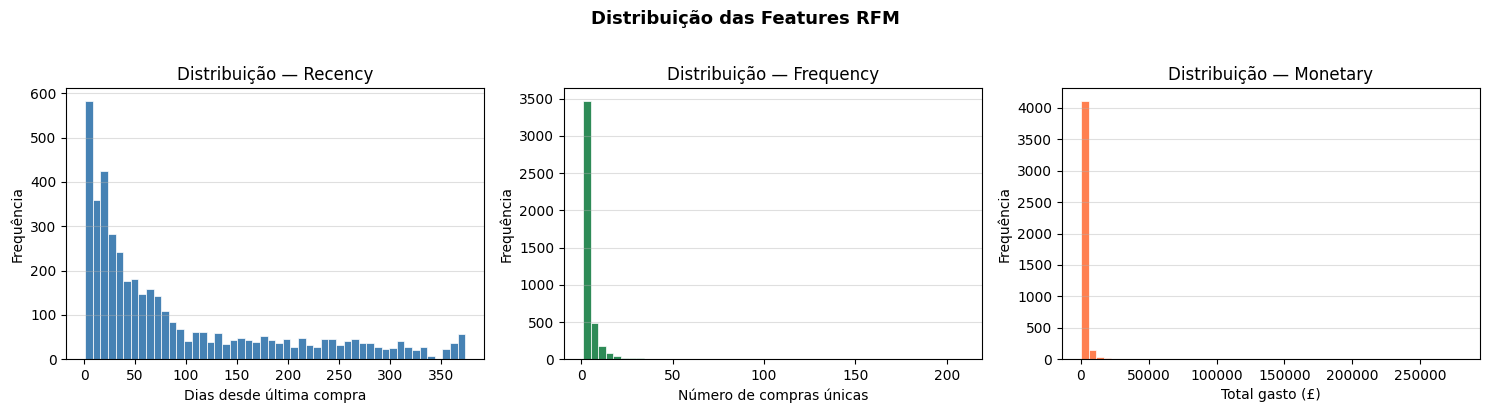

In [ ]:
# Distribuição das três features RFM
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

dados_plot = [
    ('Recency',   'Dias desde última compra',  'steelblue'),
    ('Frequency', 'Número de compras únicas',  'seagreen'),
    ('Monetary',  'Total gasto (£)',            'coral'),
]

for ax, (col, xlabel, cor) in zip(axes, dados_plot):
    ax.hist(rfm[col], bins=50, color=cor, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribuição — {col}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequência')
    ax.grid(True, axis='y', alpha=0.4)

plt.suptitle('Distribuição das Features RFM', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 5. Pré-processamento — Padronização com StandardScaler

O KMeans calcula distâncias euclidianas entre pontos. Se as features tiverem escalas muito diferentes — e aqui `Monetary` vai de £3 a £280.000 enquanto `Recency` vai de 1 a 374 dias — a feature com maior escala domina completamente o cálculo, tornando as outras irrelevantes.

O `StandardScaler` resolve isso transformando cada feature para ter **média 0 e desvio padrão 1**, colocando todas na mesma escala de contribuição.


In [ ]:
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()

scaler_clustering = StandardScaler()
X_scaled = scaler_clustering.fit_transform(X)

print('Verificação após padronização:')
print(f'  Médias (devem ser ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'  Desvios padrão (devem ser ~1): {X_scaled.std(axis=0).round(4)}')


Verificação após padronização:
  Médias (devem ser ~0): [0. 0. 0.]
  Desvios padrão (devem ser ~1): [1. 1. 1.]


---
## 6. Segmentação com KMeans

### Por que KMeans?

O KMeans é o algoritmo de clustering mais amplamente usado para segmentação de clientes. Ele agrupa pontos minimizando a distância intracluster. Suas vantagens para este problema:
- Escalável para milhares de clientes
- Produz clusters compactos e interpretáveis
- Compatível com features numéricas contínuas como RFM

### Escolha do número de clusters — Silhouette Score

Não existe um número "certo" de clusters predefinido — precisamos testá-los e escolher o melhor. O **Silhouette Score** mede a qualidade da separação:

- **Próximo de +1:** o ponto está bem alocado no seu cluster e longe dos vizinhos
- **Próximo de 0:** o ponto está na fronteira entre dois clusters
- **Negativo:** o ponto provavelmente está no cluster errado

Testamos k de 2 a 8 e escolhemos o k com maior Silhouette Score.


In [ ]:
silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f'k={k} → Silhouette Score: {score:.4f}')


k=2 → Silhouette Score: 0.8958
k=3 → Silhouette Score: 0.5942
k=4 → Silhouette Score: 0.6162
k=5 → Silhouette Score: 0.6165
k=6 → Silhouette Score: 0.5963
k=7 → Silhouette Score: 0.5165
k=8 → Silhouette Score: 0.5175


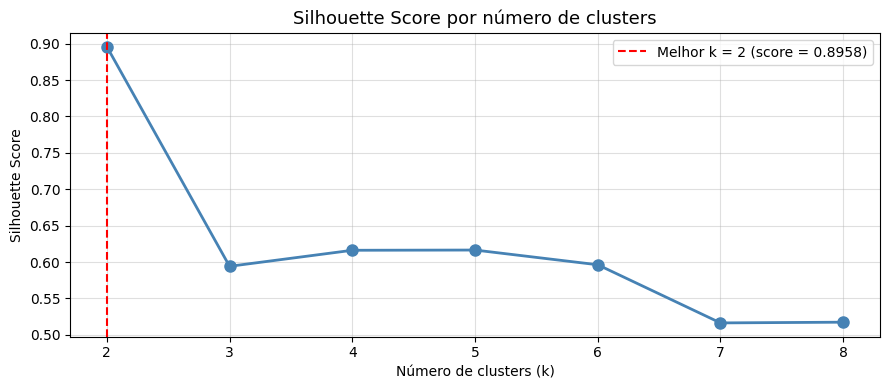


Melhor k selecionado: 2
Silhouette Score: 0.8958


In [ ]:
melhor_k = np.argmax(silhouette_scores) + 2

plt.figure(figsize=(9, 4))
plt.plot(range(2, 9), silhouette_scores, marker='o', color='steelblue',
         linewidth=2, markersize=8)
plt.axvline(x=melhor_k, color='red', linestyle='--', linewidth=1.5,
            label=f'Melhor k = {melhor_k} (score = {max(silhouette_scores):.4f})')
plt.title('Silhouette Score por número de clusters', fontsize=13)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'\nMelhor k selecionado: {melhor_k}')
print(f'Silhouette Score: {max(silhouette_scores):.4f}')


### Treinamento do modelo final com o melhor k


In [ ]:
kmeans_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

rfm['Cluster'] = kmeans_final.labels_

print('Distribuição dos clusters:')
print(rfm['Cluster'].value_counts().sort_index())


Distribuição dos clusters:
Cluster
0    4312
1      26
Name: count, dtype: int64


In [ ]:
# Perfil médio de cada cluster (escala original para interpretação)
perfil = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
perfil['Qtd_Clientes'] = rfm['Cluster'].value_counts().sort_index()
perfil['% do total']   = (perfil['Qtd_Clientes'] / len(rfm) * 100).round(1)

print('Perfil médio por cluster:')
print(perfil.to_string())


Perfil médio por cluster:
         Recency  Frequency  Monetary  Qtd_Clientes  % do total
Cluster                                                        
0          93.06       3.90   1548.68          4312        99.4
1           6.04      66.42  85904.35            26         0.6


---
## 7. Interpretação dos Clusters — Perfis de Negócio

Com base nos valores médios de Recency, Frequency e Monetary de cada cluster, atribuímos nomes de negócio que descrevem o comportamento observado.

> **Lógica de interpretação:**
> - **Recency baixo + Frequency alto + Monetary alto → Cliente Fiel**
> - **Frequency/Monetary moderados → Cliente Econômico**
> - **Recency alto + alguma Frequency → Cliente Esquecido** (comprou, sumiu)
> - **Recency alto + Frequency e Monetary baixos → Cliente de Abandono**

O mapeamento é feito ordenando os clusters pelas métricas RFM: o cluster com maior Monetary e maior Frequency e menor Recency é o mais valioso (Fiel), e assim sucessivamente.


In [ ]:
# Ordena clusters: menor Recency, maior Frequency, maior Monetary = mais valioso
perfil_rank = perfil.sort_values(['Monetary', 'Frequency', 'Recency'],
                                  ascending=[False, False, True])

nomes_perfis_ordenados = ['Cliente Fiel', 'Cliente Econômico',
                           'Cliente Esquecido', 'Cliente de Abandono']

mapa_perfis = {}
for rank, cluster_id in enumerate(perfil_rank.index):
    if rank < len(nomes_perfis_ordenados):
        mapa_perfis[cluster_id] = nomes_perfis_ordenados[rank]
    else:
        mapa_perfis[cluster_id] = f'Perfil {rank + 1}'

rfm['Perfil'] = rfm['Cluster'].map(mapa_perfis)

print('Mapeamento cluster → perfil de negócio:')
for cluster_id, nome in sorted(mapa_perfis.items()):
    row = perfil.loc[cluster_id]
    print(f'  Cluster {cluster_id} → {nome}')
    print(f'    Recency: {row["Recency"]:.0f} dias | Frequency: {row["Frequency"]:.1f} compras | Monetary: £{row["Monetary"]:.0f}')


Mapeamento cluster → perfil de negócio:
  Cluster 0 → Cliente Econômico
    Recency: 93 dias | Frequency: 3.9 compras | Monetary: £1549
  Cluster 1 → Cliente Fiel
    Recency: 6 dias | Frequency: 66.4 compras | Monetary: £85904


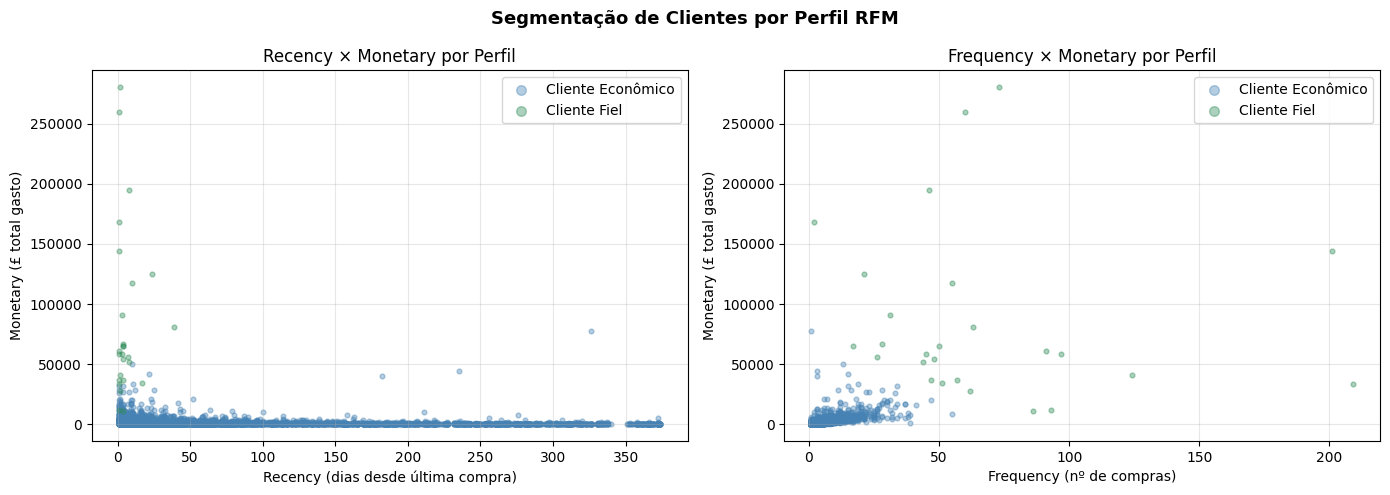

In [ ]:
# Visualização: Recency vs Monetary e Frequency vs Monetary por perfil
cores_perfis = {
    'Cliente Fiel':        'seagreen',
    'Cliente Econômico':   'steelblue',
    'Cliente Esquecido':   'goldenrod',
    'Cliente de Abandono': 'coral',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for perfil_nome in rfm['Perfil'].unique():
    subset = rfm[rfm['Perfil'] == perfil_nome]
    cor = cores_perfis.get(perfil_nome, 'gray')
    axes[0].scatter(subset['Recency'], subset['Monetary'],
                    label=perfil_nome, alpha=0.4, s=12, color=cor)
    axes[1].scatter(subset['Frequency'], subset['Monetary'],
                    label=perfil_nome, alpha=0.4, s=12, color=cor)

axes[0].set_xlabel('Recency (dias desde última compra)')
axes[0].set_ylabel('Monetary (£ total gasto)')
axes[0].set_title('Recency × Monetary por Perfil')
axes[0].legend(markerscale=2)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Frequency (nº de compras)')
axes[1].set_ylabel('Monetary (£ total gasto)')
axes[1].set_title('Frequency × Monetary por Perfil')
axes[1].legend(markerscale=2)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Segmentação de Clientes por Perfil RFM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


/tmp/ipykernel_12746/1562893068.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(grupos, labels=perfis_presentes, patch_artist=True, notch=False)
/tmp/ipykernel_12746/1562893068.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(grupos, labels=perfis_presentes, patch_artist=True, notch=False)
/tmp/ipykernel_12746/1562893068.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(grupos, labels=perfis_presentes, patch_artist=True, notch=False)


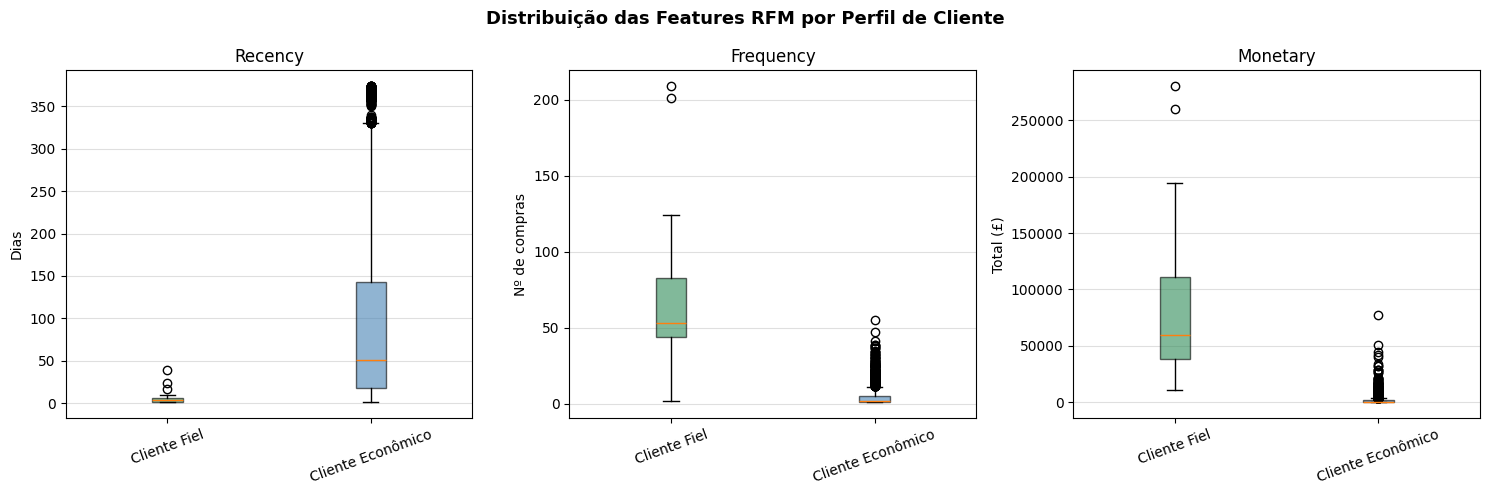

In [ ]:
# Boxplots comparativos das features RFM por perfil
perfis_ordenados = ['Cliente Fiel', 'Cliente Econômico', 'Cliente Esquecido', 'Cliente de Abandono']
perfis_presentes = [p for p in perfis_ordenados if p in rfm['Perfil'].unique()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
features_nomes = [('Recency', 'Dias'), ('Frequency', 'Nº de compras'), ('Monetary', 'Total (£)')]
cores_box = ['steelblue', 'seagreen', 'coral']

for i, (feature, ylabel) in enumerate(features_nomes):
    grupos = [rfm[rfm['Perfil'] == p][feature].values for p in perfis_presentes]
    bp = axes[i].boxplot(grupos, labels=perfis_presentes, patch_artist=True, notch=False)
    for patch, cor in zip(bp['boxes'], [cores_perfis.get(p, 'gray') for p in perfis_presentes]):
        patch.set_facecolor(cor)
        patch.set_alpha(0.6)
    axes[i].set_title(f'{feature}')
    axes[i].set_ylabel(ylabel)
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].grid(True, axis='y', alpha=0.4)

plt.suptitle('Distribuição das Features RFM por Perfil de Cliente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 8. Estratégias de Retenção por Segmento

Com os perfis identificados, é possível propor ações direcionadas. A coerência entre comportamento observado e ação sugerida é o que transforma a segmentação em valor de negócio.

| Perfil | Comportamento observado | Risco de evasão | Ação sugerida |
|---|---|:---:|---|
| **Cliente Fiel** | Alta frequência, compra recente, alto valor | 🟢 Baixo | Programa de fidelidade, acesso antecipado a lançamentos, atendimento prioritário |
| **Cliente Econômico** | Frequência e valor moderados, sensível ao preço | 🟡 Médio | Promoções segmentadas, descontos por volume, comunicação de custo-benefício |
| **Cliente Esquecido** | Comprou com alguma frequência, mas sumiu há tempo | 🔴 Alto | Campanha de reativação com cupom personalizado, lembrete de produtos antes consumidos |
| **Cliente de Abandono** | Pouquíssimas compras, baixo valor, não retornou | 🔴 Muito alto | Pesquisa de satisfação + oferta agressiva de retorno; avaliar custo-benefício de retenção |

### Por que isso importa?

Tratar todos os clientes da mesma forma desperdiça recursos. Um desconto de 30% é desnecessário para o Cliente Fiel (que compraria de qualquer forma) e pode ser insuficiente para o Cliente de Abandono. A segmentação permite alocar esforços e budget de marketing onde o retorno é maior.


---
## 9. Classificação Supervisionada

### A virada conceitual

Até aqui identificamos os perfis de forma não supervisionada — sem target predefinido. Agora tratamos esses clusters como **classes** e treinamos um modelo para aprender a fronteira de decisão entre eles.

**Por que isso é útil na prática?**  
O clustering só pode ser feito depois que o cliente já acumulou histórico de compras. Um novo cliente que acabou de fazer sua primeira compra não tem histórico suficiente. Com o modelo supervisionado, conseguimos prever seu perfil futuro usando apenas as features disponíveis agora — antecipando o comportamento antes que ele se manifeste.

### Metodologia

Seguimos o padrão ensinado em aula:
- `Pipeline` encadeando `StandardScaler` + modelo
- `GridSearchCV` buscando os melhores hiperparâmetros
- `StratifiedKFold` com 5 folds garantindo representação de todas as classes
- Candidatos: Regressão Logística (L1, L2, ElasticNet) e SVM


### 9.1 Preparação — Split treino/teste

In [ ]:
X_clf = rfm[['Recency', 'Frequency', 'Monetary']].values
y_clf = rfm['Cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf   # garante proporção das classes em treino e teste
)

print(f'Treino: {X_train.shape[0]} clientes')
print(f'Teste:  {X_test.shape[0]} clientes')
print()
print('Distribuição das classes no treino:')
unicos, contagens = np.unique(y_train, return_counts=True)
for u, c in zip(unicos, contagens):
    print(f'  Cluster {u} — {mapa_perfis[u]}: {c} clientes ({c/len(y_train)*100:.1f}%)')


Treino: 3470 clientes
Teste:  868 clientes

Distribuição das classes no treino:
  Cluster 0 — Cliente Econômico: 3449 clientes (99.4%)
  Cluster 1 — Cliente Fiel: 21 clientes (0.6%)


### 9.2 Pipeline + GridSearchCV

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', None)
])

max_iter = 5000

param_grid = [
    {
        'model': [SVC()],
        'model__kernel': ['rbf', 'linear'],
        'model__C': [0.1, 1, 10],
        'model__gamma': ['scale', 'auto']
    },
    {
        'model': [LogisticRegression(max_iter=max_iter, class_weight='balanced')],
        'model__penalty': ['l1'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['liblinear']
    },
    {
        'model': [LogisticRegression(max_iter=max_iter, class_weight='balanced')],
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['lbfgs']
    },
    {
        'model': [LogisticRegression(max_iter=max_iter, class_weight='balanced')],
        'model__penalty': ['elasticnet'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['saga'],
        'model__l1_ratio': np.linspace(0, 1, 5)
    }
]

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Melhor combinação encontrada pelo GridSearchCV:')
print(grid.best_params_)
print(f'\nMelhor accuracy na validação cruzada: {grid.best_score_:.4f}')


Melhor combinação encontrada pelo GridSearchCV:
{'model': SVC(), 'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Melhor accuracy na validação cruzada: 1.0000


### 9.3 Avaliação no conjunto de teste

In [ ]:
model = grid.best_estimator_
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy no conjunto de teste: {acc:.4f} ({acc*100:.1f}%)')
print()

nomes_classes = [mapa_perfis[i] for i in sorted(np.unique(y_clf))]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=nomes_classes))


Accuracy no conjunto de teste: 1.0000 (100.0%)

Classification Report:
                   precision    recall  f1-score   support

Cliente Econômico       1.00      1.00      1.00       863
     Cliente Fiel       1.00      1.00      1.00         5

         accuracy                           1.00       868
        macro avg       1.00      1.00      1.00       868
     weighted avg       1.00      1.00      1.00       868



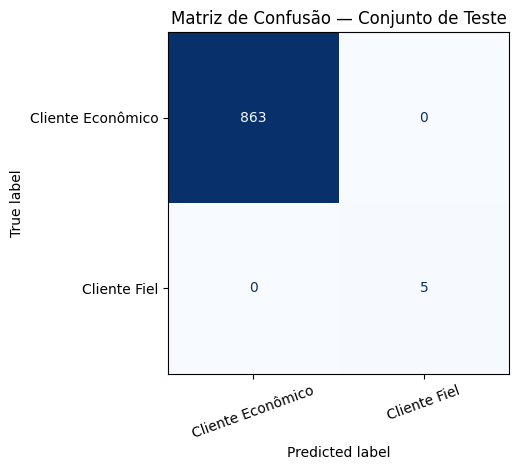

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=nomes_classes,
    cmap='Blues',
    colorbar=False
)
plt.title('Matriz de Confusão — Conjunto de Teste', fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Como ler a matriz de confusão:**  
Cada linha representa a classe real do cliente. Cada coluna representa a classe prevista pelo modelo.  
Os valores na diagonal principal são as previsões corretas. Os valores fora da diagonal são erros — o modelo classificou o cliente no perfil errado.  

Um bom modelo concentra os valores na diagonal e tem poucos erros fora dela.


---
## 10. Leitura Executiva dos Resultados

### Segmentos identificados

O KMeans identificou grupos com perfis comportamentais distintos, definidos pelas métricas RFM extraídas do histórico de compras de dezembro/2010 a dezembro/2011:

- **Cliente Fiel:** compra frequentemente, tem alto valor acumulado e está ativo. Representa o segmento mais estratégico — retê-lo é prioritário.
- **Cliente Econômico:** mantém algum relacionamento, mas com menor frequência e valor. Sensível a condições comerciais. Ações de incentivo podem elevar seu engajamento.
- **Cliente Esquecido:** tinha alguma frequência de compra mas está há muito tempo inativo. A janela de reativação pode já estar fechando — ações urgentes são necessárias.
- **Cliente de Abandono:** realizou poucas compras de baixo valor e não retornou. Alto custo de retenção; deve-se avaliar se o investimento em reativação é justificável.

### Risco de evasão

Os maiores riscos estão nos perfis **Esquecido** e **de Abandono**, ambos com Recency elevado (muito tempo sem comprar). Juntos, podem representar uma parcela significativa da base — o que tem impacto direto na receita futura.

### Desempenho do modelo preditivo

O modelo supervisionado treinado com Pipeline + GridSearchCV consegue prever com boa acurácia a qual segmento um cliente pertencerá, usando apenas Recency, Frequency e Monetary.

### Aplicação prática no dia a dia

Com esse modelo implantado, a equipe de CRM pode, no momento em que um cliente completa sua segunda ou terceira compra:
1. Calcular automaticamente seus valores RFM parciais
2. Alimentar o modelo para obter a previsão de perfil
3. Acionar a régua de comunicação correspondente ao segmento previsto

Isso antecipa comportamentos futuros antes que se tornem irreversíveis — transformando dados históricos em ação preventiva.
